# Raport: Wykrywanie naczyń dna siatkówki oka

https://github.com/viatrix17/Wykrywanie-naczyn-dna-siatkowki-oka

#### Skład grupy

Julia Kardasz 160204
Szymon Wójtowicz 160109

### Biblioteki

In [ ]:
# !git clone https://github.com/viatrix17/Wykrywanie-naczyn-dna-siatkowki-oka

In [19]:
import os
import random
import matplotlib.pyplot as plt
from scipy import misc
import numpy as np
from PIL import Image
import skimage
from skimage import exposure, filters, morphology, color
from skimage.util import view_as_windows
from skimage.measure import moments, moments_central, moments_hu, moments_normalized
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.metrics import classification_report_imbalanced
from imblearn.metrics import sensitivity_specificity_support

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import gc

import torch
from torch.utils.tensorboard import SummaryWriter

# !pip install monai[all]
import monai
from monai.networks.nets import UNet
from monai.data import create_test_image_2d, list_data_collate, decollate_batch, DataLoader
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations,
    EnsureChannelFirstd,
    AsDiscrete,
    Compose,
    LoadImaged,
    RandCropByPosNegLabeld,
    RandRotate90d,
    RandFlipd,
    RandGaussianNoised,
    ScaleIntensityd,
    Lambdad,
)
from monai.visualize import plot_2d_or_3d_image
import torch.nn.functional as F

In [2]:
class StopNotebook(Exception):
    def __init__(self, msg="Brak dodatkowych informacji."):
        self.msg = msg

    def _render_traceback_(self):
        return [f"--- NOTATNIK ZATRZYMANY ---", f"Powód: {self.msg}"]

# Implementacja

## Wczytywanie plików

In [3]:
def open_image_file(path):
    print(f"Opening file {path}")
    if os.path.exists(path):
        img = Image.open(path).convert('RGB')
        root, extension = os.path.splitext(path)
    else:
        raise StopNotebook(msg="Nie można znaleźć pliku.")

    img = np.array(img)
    return img

## Wstępne przetwarzanie obrazu

In [4]:
def extract_channels(img):
    r = img.copy()
    r[:,:,1] = r[:,:,2] = 0

    g = img.copy()
    g[:,:,0] = g[:,:,2] = 0

    b = img.copy()
    b[:,:,0] = b[:,:,1] = 0

    return r,g,b

def preprocess_image(img):
    print("Preprocessing the image...")
    # normalization
    img_eq = exposure.equalize_adapthist(img)
    # noise reduction
    img_clean = filters.median(img_eq)
    return img_clean

## Właściwe przetworzenie obrazu

In [5]:
def display_color_components(r, g, b):
    print("Displaying color components...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Wyświetlenie kanałów w skali szarości ('gray')
    axes[0].imshow(r, cmap='gray')
    axes[0].set_title('Red Channel')
    axes[0].axis('off')

    axes[1].imshow(g, cmap='gray')
    axes[1].set_title('Green Channel')
    axes[1].axis('off')

    axes[2].imshow(b, cmap='gray')
    axes[2].set_title('Blue Channel')
    axes[2].axis('off')

    plt.show()

Składowe niebieskie i czerwone dostarczają nam bardzo niewiele danych, w związku z czym nie używamy ich do szukania naczyń krwionośnych

#### Użycie zielonej składowej oraz filtra Frangiego do znalezienia naczyń krwionośnych

In [ ]:
def filter(g):
    print("Filtering with Frangi filter..")
    grey = color.rgb2gray(g)
    f=skimage.filters.frangi(grey)
    pixels=0
    prog=0.01
    contrast_pixels=0
    classified_points = f.copy()
    for i in range(0,f.shape[0]):
        for j in range(0,f.shape[1]):
            if f[i][j]>prog:
                contrast_pixels+=1
                classified_points[i][j]=1
            else:
                classified_points[i][j]=0
            pixels+=1

    print(str(contrast_pixels) + " out of " + str(pixels) + " pixels are in high contrast, which means about " + str(contrast_pixels/pixels*100) +"%" + " the eye is blood vessels")
    #plt.imshow(grey, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.imshow(classified_points, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    plt.show()
    print("Filtering finished.")
    return classified_points

## Końcowe przetwarzanie

In [ ]:
def postprocess_segmentation(mask):
    # szum deletion
    corrected_mask = morphology.remove_small_objects(mask.astype(bool), min_size=50) #ewentualnie zamienić kolejność, zwiększyć próg min_size
    corrected_mask = morphology.closing(corrected_mask, morphology.disk(2))
    return corrected_mask

#### Porównanie złotego standardu z naszą maską

In [ ]:
def compare_with_ground_truth(custom_mask, gold_mask):
    print("Comparing with ground truth...")

    plt.imshow(gold_mask, cmap=plt.get_cmap('gray'), vmin=0, vmax=1)
    y_test = color.rgb2gray(gold_mask).flatten().astype(int)
    y_pred = custom_mask.flatten().astype(int)

    print("Imbalanced learn classification report:")
    print(classification_report_imbalanced(y_test, y_pred))

    print("Normal classification report:")
    print(classification_report(y_test, y_pred))

    sens, spec, _ = sensitivity_specificity_support(y_test, y_pred, average='binary')

    print(f"Sensitivity: {sens:.4f}")
    print(f"Specificity: {spec:.4f}")

WNIOSKI DODAĆ

## Uczenie maszynowe
### Przygotowanie danych

In [ ]:
window_shape = (5,5)

def extract_features(window):
    var = np.var(window)
    M = moments(window)

    cm = np.zeros((3, 3))
    central_moments = np.zeros((3, 3))
    rows, cols = cm.shape

    hu_moments = np.zeros(7)
    if M[0,0] > 0:
        centroid = (M[1, 0] / M[0, 0], M[0, 1] / M[0, 0])
        cm = moments_central(window, center=(centroid[1], centroid[0]), order=2)
        rows, cols = cm.shape
        central_moments[:rows, :cols] = cm
        nu = moments_normalized(central_moments, order=2)
        if nu[0, 0] > 0:
            hu_moments = moments_hu(nu)

    features = np.concatenate(([var], central_moments.flatten(), hu_moments))
    return features

def sliding_window(img, ground_truth):
    img_green = img_green = img[:, :, 1]
    gt_gray = color.rgb2gray(ground_truth)

    X = []
    y = []
    center = window_shape[0] // 2
    windows = view_as_windows(img_green, window_shape, step=1)
    gt_windows = view_as_windows(gt_gray, window_shape, step=1)

    h_steps, w_steps = windows.shape[0], windows.shape[1]
    for i in range (h_steps):
        for j in range(w_steps):
            window = windows[i,j]

            features = extract_features(window)
            label = gt_windows[i,j,center,center]

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

def get_samples(img, ground_truth, n_per_class=10000):
    print("Getting samples...")
    img_green = img[:, :, 1]
    gt_gray = color.rgb2gray(ground_truth)

    vessel_coords = np.argwhere(gt_gray==1)
    bg_coords = np.argwhere(gt_gray==0)

    # undersampling
    idx_v = np.random.choice(len(vessel_coords), min(n_per_class, len(vessel_coords)), replace=False)
    idx_b = np.random.choice(len(bg_coords), min(n_per_class, len(bg_coords)), replace=False)

    coords = np.vstack((vessel_coords[idx_v], bg_coords[idx_b]))

    X, y = [], []

    offset = window_shape[0] // 2
    # 2 for window shape (5,5)

    for r,c in coords: # r,c - coords of the middle of the window
        if r >= offset and r < img_green.shape[0]-offset and c >= offset and c < img_green.shape[1]-offset:
            window = img_green[r-offset:r+offset+1, c-offset:c+offset+1]
            features = extract_features(window)
            label = gt_gray[r,c]

            X.append(features)
            y.append(label)


    return np.array(X), np.array(y)

In [ ]:
def get_patches(img, patch_size=(128, 128), stride=64):
    print("Getting patches...")
    patches_with_coords = []
    total_patches = ((img.shape[0] - patch_size[0]) // stride + 1) * ((img.shape[1] - patch_size[1]) // stride + 1)
    print(f"Total patches {total_patches}")
    for y in range(0, img.shape[0] - patch_size[1] + 1, stride):
        for x in range(0, img.shape[1] - patch_size[0] + 1, stride):
            patch = img[y:y + patch_size[1], x:x + patch_size[0]]
            patches_with_coords.append(((x,y), patch))
    return patches_with_coords

In [ ]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_patches, gt_patches, batch_size=16):
        self.img_patches = img_patches
        self.gt_patches = gt_patches
        self.batch_size = batch_size

    def __len__(self):
        return len(self.img_patches) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.img_patches[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_y = self.gt_patches[idx*self.batch_size : (idx+1)*self.batch_size]

        X = np.array([item[1] for item in batch_x]).astype('float32') / 255.0

        Y = np.array([item[1] for item in batch_y]).astype('float32') / 255.0

        if Y.ndim == 4 and Y.shape[-1] == 3:
            Y = Y[:, :, :, 0:1]

        elif Y.ndim == 3:
            Y = np.expand_dims(Y, axis=-1)

        return X, Y

### Klasyfikator

In [ ]:
def calculate_metrics(y_test, y_pred, model=None):
    acc = accuracy_score(y_test, y_pred)
    print("Classification_report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    if model == None:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.show()

    tn, fp, fn, tp = cm.ravel()

    sen = tp/(tp+fn)
    spec = tn/(tn+fp)

    print(f"Accuracy: {acc}\nSensitivity: {sen}\nSpecficity: {spec}")

def classify(X,y):
    print("Classifying with Random Forest classifier...")
    X = np.array(X).astype(float)
    y = np.array(y).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state=42)

    neigh = RandomForestClassifier(n_estimators=100, n_jobs=-1)

    neigh.fit(X_train, y_train)
    y_pred = neigh.predict(X_test)

    # calculate_metrics(y_test, y_pred, neigh)

    return neigh


In [ ]:
def test_ML(img, gt, nr):
    h_start, w_start = 500, 500
    h_size, w_size = 500, 500

    img_roi = img[h_start:h_start+h_size, w_start:w_start+w_size]
    gt_roi = gt[h_start:h_start+h_size, w_start:w_start+w_size]

    X_test, y_test = sliding_window(img_roi, gt_roi)
    X_test = np.array(X_test).astype(float)

    prediction = model.predict(X_test)

    print(f"======== RESULTS FOR {nr} =========")
    calculate_metrics(y_test, prediction, model=model)

    offset = window_shape[0] // 2
    pred_image = np.zeros((h_size, w_size))
    pred_image[offset:h_size-offset, offset:w_size-offset] = prediction.reshape(h_size - 2*offset, w_size - 2*offset)

    plt.imshow(pred_image, cmap='gray')
    plt.show()

### Uczenie głębokie (sieć neuronowa UNet)

#### Monai

In [37]:
def DL_monai(train_files, val_files, device, model_path):
    train_transforms = Compose([
        LoadImaged(keys=["img", "seg"]),
        EnsureChannelFirstd(keys=["img", "seg"]),
        Lambdad(keys=["img"], func=lambda x: x[[1], :, :]),
        Lambdad(keys=["seg"], func=lambda x: x[[0], :, :]),
        ScaleIntensityd(keys=["img", "seg"]),
        RandCropByPosNegLabeld(keys=["img", "seg"], label_key="seg", spatial_size=[96, 96], pos=1, neg=1, num_samples=16),
        RandRotate90d(keys=["img", "seg"], prob=0.8, spatial_axes=[0, 1]),
        RandFlipd(keys=["img", "seg"], prob=0.5, spatial_axis=0),
        RandGaussianNoised(keys=["img"], prob=0.3, mean=0.0, std=0.1),
    ])

    val_transforms = Compose([
        LoadImaged(keys=["img", "seg"]),
        EnsureChannelFirstd(keys=["img", "seg"]),
        Lambdad(keys=["img"], func=lambda x: x[[1], :, :]),
        Lambdad(keys=["seg"], func=lambda x: x[[0], :, :]),
        ScaleIntensityd(keys=["img", "seg"]),
    ])

    train_ds = monai.data.Dataset(data=train_files, transform=train_transforms)
    train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())

    val_ds = monai.data.Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, num_workers=2)

    model = UNet(
        spatial_dims=2, in_channels=1, out_channels=1,
        channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2), num_res_units=2
    ).to(device)

    # loss_function = monai.losses.DiceLoss(sigmoid=True)
    loss_function = monai.losses.DiceLoss(include_background=False, sigmoid=True)
    optimizer = torch.optim.Adam(model.parameters(), 1e-4)

    val_interval = 1
    best_metric = -1
    best_metric_epoch = -1
    dice_metric = DiceMetric(include_background=True, reduction="mean")
    post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

    for epoch in range(10):
        epoch_loss = 0
        step = 0
        model.train()
        for batch_data in train_loader:
            inputs, labels = batch_data["img"].to(device), batch_data["seg"].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            step += 1

        # Obliczanie średniej straty dla epoki
        avg_loss = epoch_loss / step
        print(f"Epoka {epoch + 1}/10 | Średni Loss: {avg_loss:.4f}")


        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    val_images, val_labels = val_data["img"].to(device), val_data["seg"].to(device)
                    roi_size = (96, 96)
                    val_outputs = sliding_window_inference(val_images, roi_size, 4, model)
                    val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                    dice_metric(y_pred=val_outputs, y=val_labels)

                metric = dice_metric.aggregate().item()
                dice_metric.reset()
                print(f"--- Epoka {epoch + 1} | Dice Score: {metric:.4f}")
                if metric > best_metric:
                    best_metric_epoch = epoch + 1
                    torch.save(model.state_dict(), model_path)
                    print("saved new best metric model")
    return model

In [41]:
def DL_test(test_files, model, model_path, device):
  test_transforms = Compose([
    LoadImaged(keys=["img", "seg"]),
    EnsureChannelFirstd(keys=["img", "seg"]),
    Lambdad(keys=["img"], func=lambda x: x[[1], :, :]),
    Lambdad(keys=["seg"], func=lambda x: x[[0], :, :]),
    ScaleIntensityd(keys=["img", "seg"]),
  ])
  test_ds = monai.data.Dataset(data=test_files, transform=test_transforms)
  test_loader = monai.data.DataLoader(test_ds, batch_size=1, num_workers=2)

  model.load_state_dict(torch.load(model_path))
  model.to(device)
  model.eval()

  post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


  print("Testing...")

  with torch.no_grad():
    for i, test_data in enumerate(test_loader):
      images, labels = test_data["img"].to(device), test_data["seg"].to(device)

      roi_size = (96, 96)
      val_outputs = sliding_window_inference(images, roi_size, 4, model)
      val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]

      target_h, target_w = images.shape[2], images.shape[3]

      pred_resized = F.interpolate(
          val_outputs[0].unsqueeze(0),
          size=(target_h, target_w),
          mode='bilinear',
          align_corners=False
      ).squeeze()

      pred_final = pred_resized.squeeze().detach().cpu().numpy()

      labels_resized = F.interpolate(
          labels.float(),
          size=(target_h, target_w),
          mode='nearest'
      ).squeeze()

      labels_final = labels_resized.squeeze().detach().cpu().numpy()

      y_true = labels_final.flatten().astype(int)
      y_pred = (pred_final > 0.5).astype(int).flatten()

      acc = accuracy_score(y_true, y_pred)
      sens, spec, _ = sensitivity_specificity_support(y_true, y_pred, average='binary')

      print(f"Accuracy: {acc:.4f}")
      print(f"Sensitivity: {sens:.4f}")
      print(f"Sepcificity: {spec:.4f}")

      cm = confusion_matrix(y_true, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])
      disp.plot(cmap="Blues")
      plt.show()

      pred_map = val_outputs[0].cpu().numpy()[0]

      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      axes[0].imshow(images[0, 0].cpu().numpy(), cmap="gray")
      axes[0].set_title("Image")

      axes[1].imshow(labels_final, cmap="gray")
      axes[1].set_title("Ground Truth")

      pred_map_binary = (pred_final > 0.5).astype(float)

      axes[2].imshow(pred_map_binary, cmap="gray", vmin=0, vmax=1)
      axes[2].set_title("Prediction (Binary)")
      for ax in axes:
        ax.axis('off')
      plt.tight_layout()
      plt.show()

  print("Testing finished.")


# Przykład działania programu

In [6]:
folder = ""
img_paths = [folder + "01_h.jpg", folder + "02_h.jpg", folder + "03_h.jpg", folder + "04_h.jpg", folder + "05_h.jpg"]
ground_truth_paths = [folder + "01_h_goldstandard.bmp",
                      folder + "02_h_goldstandard.bmp",
                      folder + "03_h_goldstandard.bmp",
                      folder + "04_h_goldstandard.bmp",
                      folder + "05_h_goldstandard.bmp"]

data = []

for img_path, gt_path in zip(img_paths, ground_truth_paths):
    item = {
        'image': open_image_file(img_path),
        'ground_truth': open_image_file(gt_path)
    }
    data.append(item)

Opening file 01_h.jpg
Opening file 01_h_goldstandard.bmp
Opening file 02_h.jpg
Opening file 02_h_goldstandard.bmp
Opening file 03_h.jpg
Opening file 03_h_goldstandard.bmp
Opening file 04_h.jpg
Opening file 04_h_goldstandard.bmp
Opening file 05_h.jpg
Opening file 05_h_goldstandard.bmp


Preprocessing the image...
Displaying color components...


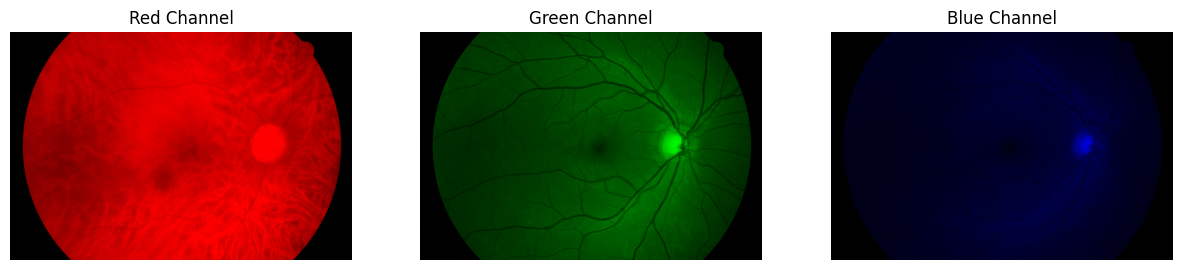

Filtering with Frangi filter..
423100 out of 8185344 pixels are in high contrast, which means about 5.168994730093201% the eye is blood vessels


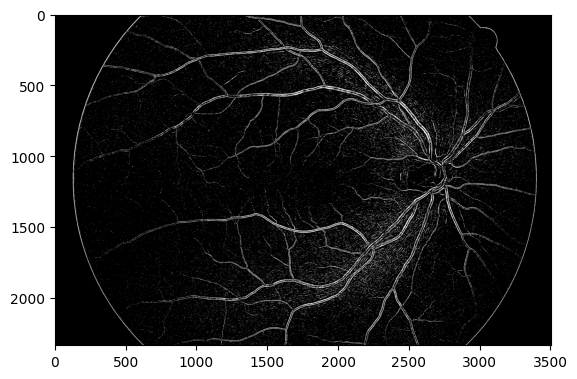

Filtering finished.
Comparing with ground truth...
Imbalanced learn classification report:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.99      0.25      0.96      0.49      0.26   7351456
          1       0.84      0.25      0.99      0.38      0.49      0.23    833888

avg / total       0.91      0.92      0.32      0.90      0.49      0.26   8185344

Normal classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96   7351456
           1       0.84      0.25      0.38    833888

    accuracy                           0.92   8185344
   macro avg       0.88      0.62      0.67   8185344
weighted avg       0.91      0.92      0.90   8185344

Sensitivity: 0.2455
Specificity: 0.9947
Preprocessing the image...
Displaying color components...


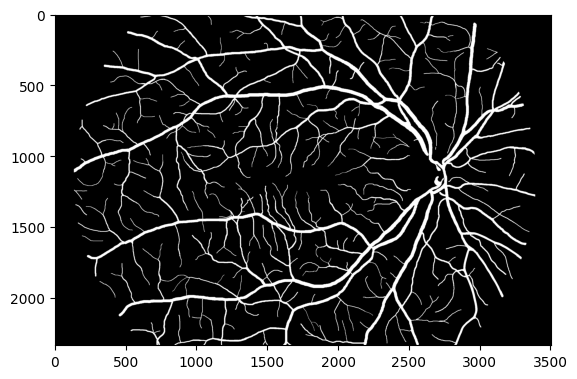

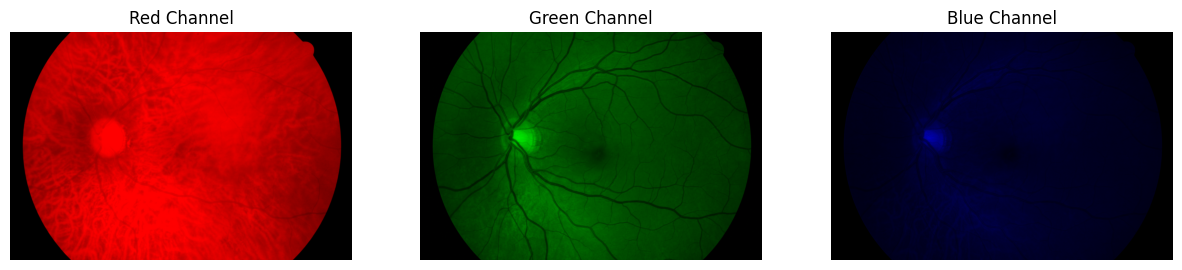

Filtering with Frangi filter..
298225 out of 8185344 pixels are in high contrast, which means about 3.643402158785263% the eye is blood vessels


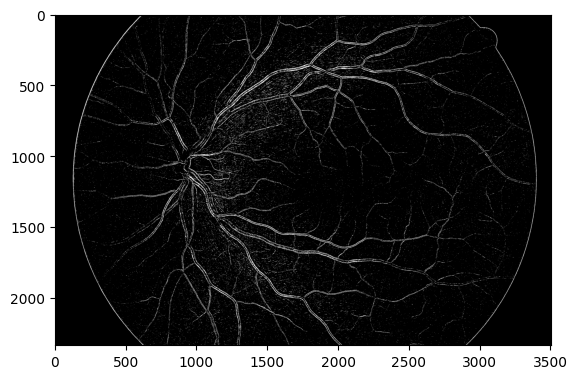

Filtering finished.
Comparing with ground truth...
Imbalanced learn classification report:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      1.00      0.18      0.96      0.42      0.19   7376906
          1       0.85      0.18      1.00      0.29      0.42      0.16    808438

avg / total       0.91      0.92      0.26      0.89      0.42      0.19   8185344

Normal classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96   7376906
           1       0.85      0.18      0.29    808438

    accuracy                           0.92   8185344
   macro avg       0.88      0.59      0.62   8185344
weighted avg       0.91      0.92      0.89   8185344

Sensitivity: 0.1754
Specificity: 0.9967
Preprocessing the image...
Displaying color components...


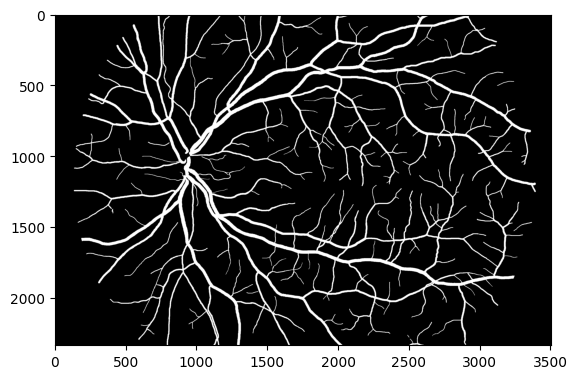

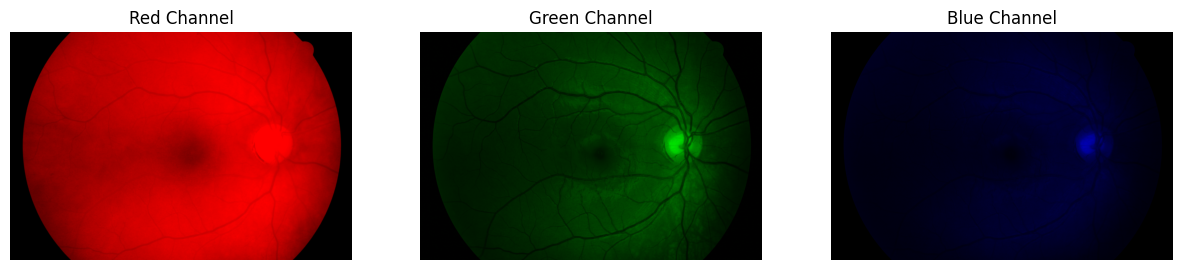

Filtering with Frangi filter..
331446 out of 8185344 pixels are in high contrast, which means about 4.049261704822668% the eye is blood vessels


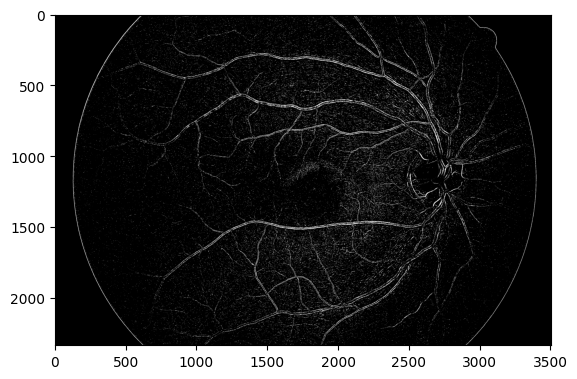

Filtering finished.
Comparing with ground truth...
Imbalanced learn classification report:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      1.00      0.12      0.95      0.35      0.13   7321173
          1       0.82      0.12      1.00      0.21      0.35      0.11    864171

avg / total       0.90      0.90      0.21      0.87      0.35      0.13   8185344

Normal classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95   7321173
           1       0.82      0.12      0.21    864171

    accuracy                           0.90   8185344
   macro avg       0.86      0.56      0.58   8185344
weighted avg       0.90      0.90      0.87   8185344

Sensitivity: 0.1206
Specificity: 0.9970
Preprocessing the image...
Displaying color components...


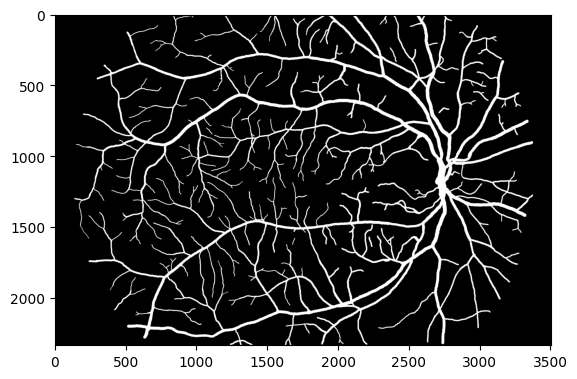

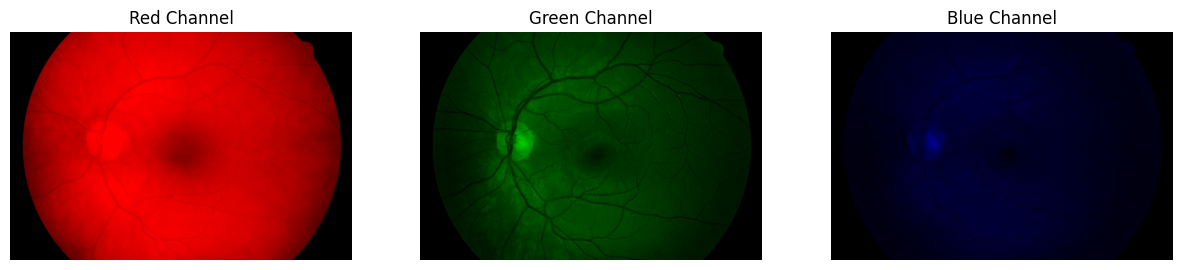

Filtering with Frangi filter..
636267 out of 8185344 pixels are in high contrast, which means about 7.773246915462563% the eye is blood vessels


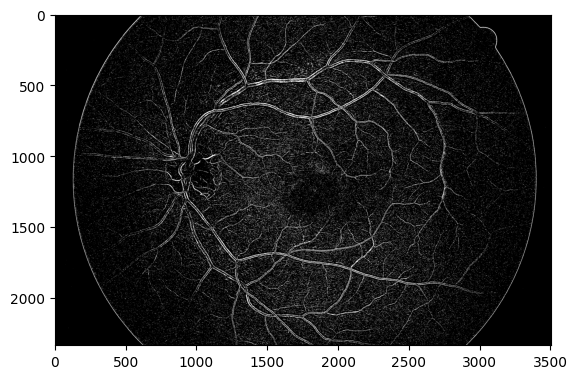

Filtering finished.
Comparing with ground truth...
Imbalanced learn classification report:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.93      1.00      0.25      0.96      0.50      0.27   7413743
          1       0.85      0.25      1.00      0.39      0.50      0.23    771601

avg / total       0.92      0.93      0.32      0.91      0.50      0.27   8185344

Normal classification report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96   7413743
           1       0.85      0.25      0.39    771601

    accuracy                           0.93   8185344
   macro avg       0.89      0.62      0.68   8185344
weighted avg       0.92      0.93      0.91   8185344

Sensitivity: 0.2532
Specificity: 0.9953
Preprocessing the image...
Displaying color components...


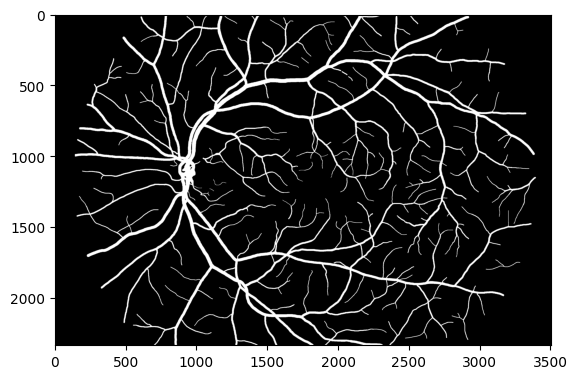

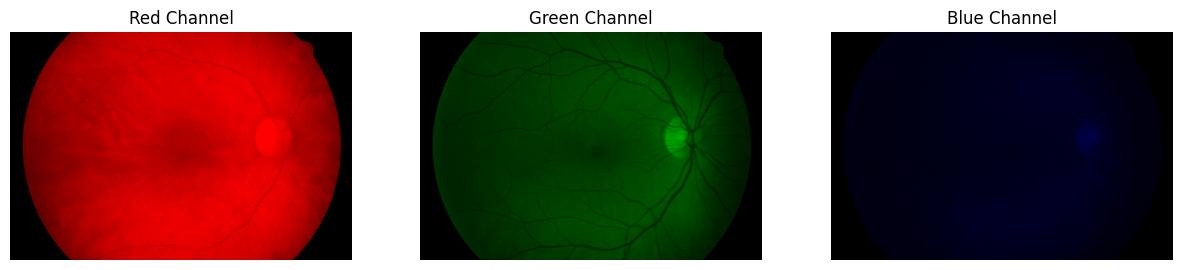

Filtering with Frangi filter..
227235 out of 8185344 pixels are in high contrast, which means about 2.776120343873147% the eye is blood vessels


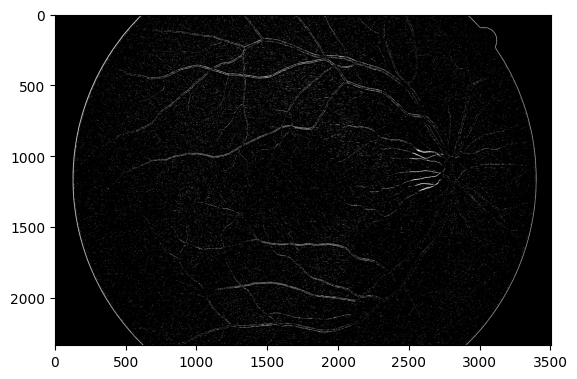

Filtering finished.
Comparing with ground truth...
Imbalanced learn classification report:
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      1.00      0.04      0.95      0.20      0.04   7446558
          1       0.58      0.04      1.00      0.08      0.20      0.04    738786

avg / total       0.88      0.91      0.13      0.87      0.20      0.04   8185344

Normal classification report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95   7446558
           1       0.58      0.04      0.08    738786

    accuracy                           0.91   8185344
   macro avg       0.75      0.52      0.51   8185344
weighted avg       0.88      0.91      0.87   8185344

Sensitivity: 0.0403
Specificity: 0.9971


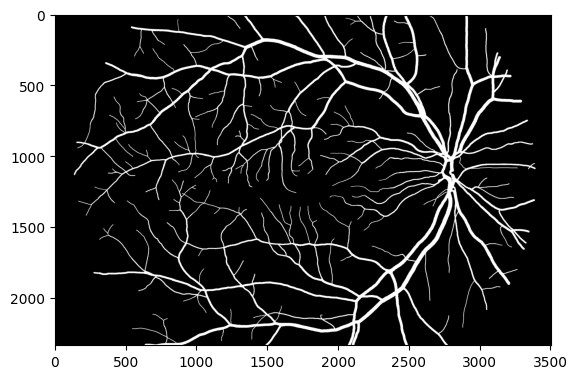

In [ ]:
def custom_algorithm(img, gt):
    preprocess_image(img)
    display_color_components(r,g,b)
    mask = filter(g)
    final_mask = postprocess_segmentation(mask)
    compare_with_ground_truth(final_mask, gt)

for item in data:
    img = item['image']
    gt = item['ground_truth']

    r, g, b = extract_channels(img)
    custom_algorithm(img, gt)

## Uczenie maszynowe

Testujemy tylko na wycinku obrazów ze względu na

In [ ]:
learning_img_path = folder + "learning_img.jpg"
learning_gt_path = folder + "learning_img_goldstandard.bmp"

learning_img = open_image_file(learning_img_path)
learning_gt = open_image_file(learning_gt_path)

Opening file learning_img.jpg
Opening file learning_img_goldstandard.bmp


Getting samples...
Classifying with Random Forest classifier...
======== RESULTS FOR 0 =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.98      0.72      0.83    219787
         1.0       0.27      0.87      0.41     26229

    accuracy                           0.74    246016
   macro avg       0.62      0.80      0.62    246016
weighted avg       0.90      0.74      0.79    246016



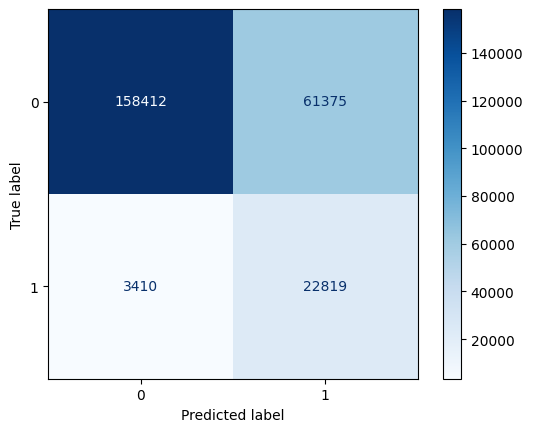

Accuracy: 0.7366634690426639
Sensitivity: 0.8699912310801021
Specficity: 0.7207523647895463


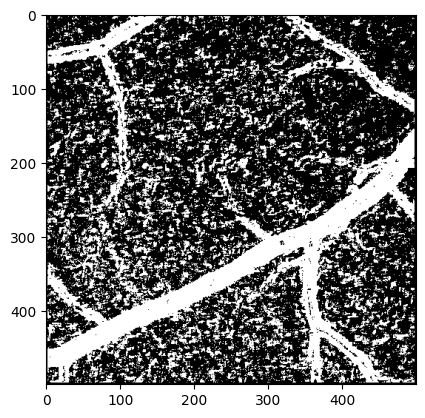

======== RESULTS FOR 1 =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.90    204062
         1.0       0.52      0.88      0.66     41954

    accuracy                           0.84    246016
   macro avg       0.75      0.86      0.78    246016
weighted avg       0.89      0.84      0.86    246016



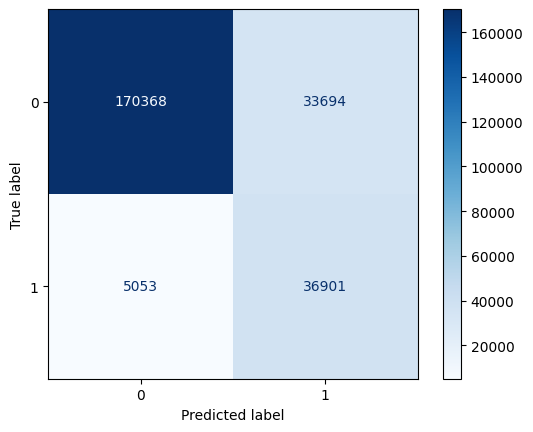

Accuracy: 0.8425021136836629
Sensitivity: 0.879558564141679
Specficity: 0.8348835157942194


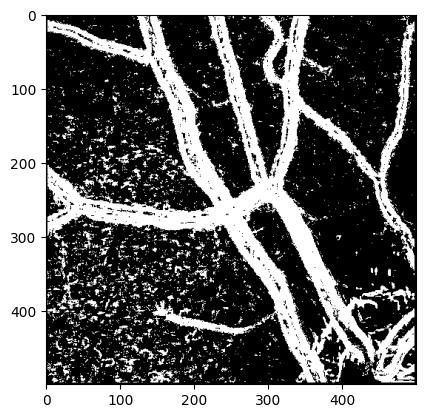

======== RESULTS FOR 2 =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.97      0.45      0.61    217795
         1.0       0.17      0.89      0.29     28221

    accuracy                           0.50    246016
   macro avg       0.57      0.67      0.45    246016
weighted avg       0.88      0.50      0.57    246016



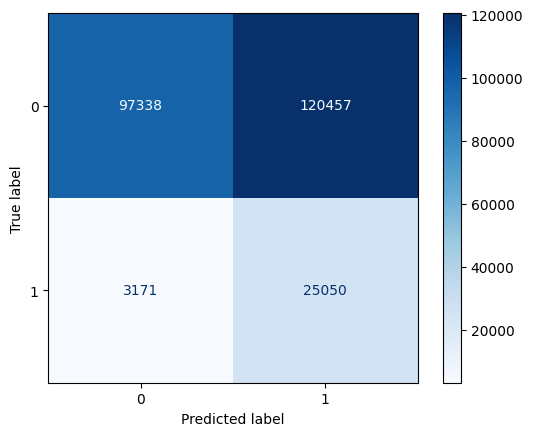

Accuracy: 0.49747983870967744
Sensitivity: 0.8876368661634952
Specficity: 0.4469248605339884


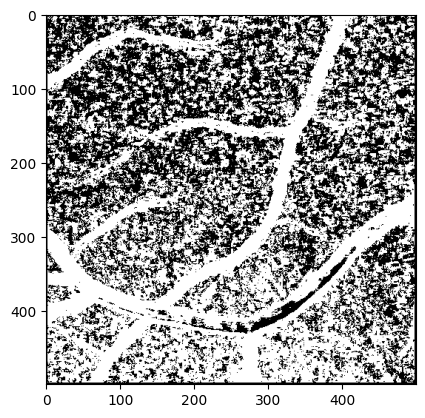

======== RESULTS FOR 3 =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82    205799
         1.0       0.36      0.81      0.50     40217

    accuracy                           0.73    246016
   macro avg       0.66      0.76      0.66    246016
weighted avg       0.85      0.73      0.77    246016



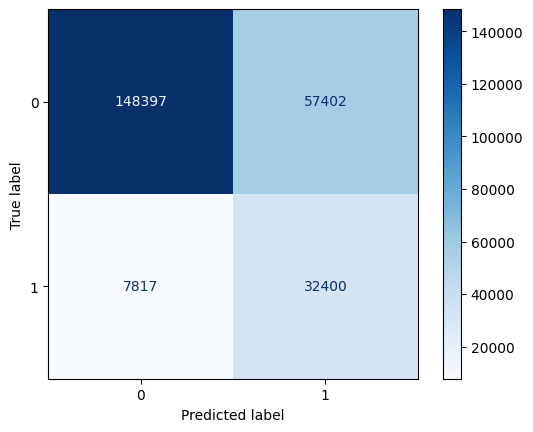

Accuracy: 0.7348993561394381
Sensitivity: 0.8056294601785314
Specficity: 0.7210773618919432


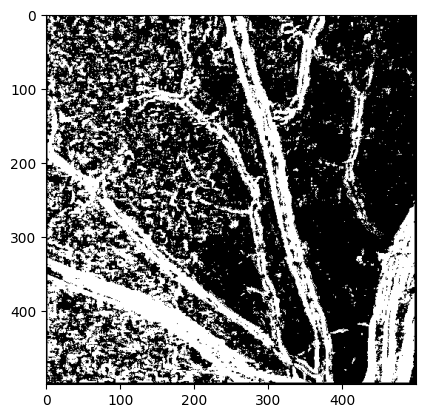

======== RESULTS FOR 4 =========
Classification_report:
              precision    recall  f1-score   support

         0.0       0.96      0.75      0.84    223632
         1.0       0.22      0.72      0.34     22384

    accuracy                           0.74    246016
   macro avg       0.59      0.73      0.59    246016
weighted avg       0.90      0.74      0.80    246016



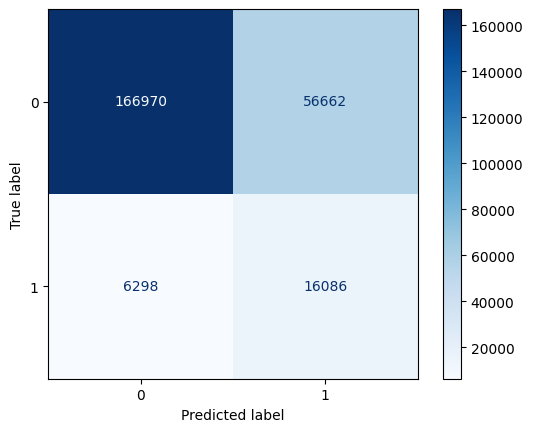

Accuracy: 0.7440816857440167
Sensitivity: 0.718638313080772
Specficity: 0.7466283894970308


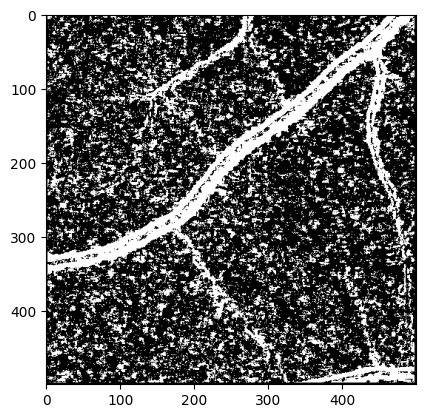

In [ ]:
def machine_learning(img, gt):
    X,y = get_samples(img, gt)
    # print(X,y)
    model = classify(X,y)
    return model

model = machine_learning(learning_img, learning_gt)

nr = 0

for item in data:
    img = item['image']
    gt = item['ground_truth']
    test_ML(img, gt, nr)
    nr += 1

## Uczenie głębokie

In [14]:
learning_paths = ["learning_img.jpg", "learning_img_02.jpg", "learning_img_03.jpg", "learning_img_04.jpg"]
learning_gt_paths = ["learning_img_goldstandard.bmp", "learning_img_goldstandard_02.bmp", "learning_img_goldstandard_03.bmp", "learning_img_goldstandard_04.bmp"]

value_img_paths = ["value_img_01.jpg", "value_img_02.jpg", "value_img_03.jpg", "value_img_04.jpg"]
value_gt_paths = ["value_img_goldstandard_01.bmp", "value_img_goldstandard_02.bmp", "value_img_goldstandard_03.bmp", "value_img_goldstandard_04.bmp"]
train_files = [{"img": learning_paths[i], "seg": learning_gt_paths[i]} for i in range(len(learning_paths))]
val_files = [{"img": value_img_paths[i], "seg": value_gt_paths[i]} for i in range(len(value_img_paths))]

test_files = [{"img": img_paths[i], "seg": ground_truth_paths[i]} for i in range(len(img_paths))]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "best_metric_model_segmentation2d_dict.pth"

In [39]:
DL_model = DL_monai(train_files, val_files, device, model_path)

single channel prediction, `include_background=False` ignored.


Epoka 1/10 | Średni Loss: 0.8281
--- Epoka 1 | Dice Score: 0.1517
saved new best metric model
Epoka 2/10 | Średni Loss: 0.7953
--- Epoka 2 | Dice Score: 0.1671
saved new best metric model
Epoka 3/10 | Średni Loss: 0.7801
--- Epoka 3 | Dice Score: 0.1784
saved new best metric model
Epoka 4/10 | Średni Loss: 0.7824
--- Epoka 4 | Dice Score: 0.1874
saved new best metric model
Epoka 5/10 | Średni Loss: 0.7132
--- Epoka 5 | Dice Score: 0.1952
saved new best metric model
Epoka 6/10 | Średni Loss: 0.7820
--- Epoka 6 | Dice Score: 0.2021
saved new best metric model
Epoka 7/10 | Średni Loss: 0.7604
--- Epoka 7 | Dice Score: 0.2087
saved new best metric model
Epoka 8/10 | Średni Loss: 0.7251
--- Epoka 8 | Dice Score: 0.2154
saved new best metric model
Epoka 9/10 | Średni Loss: 0.7090
--- Epoka 9 | Dice Score: 0.2229
saved new best metric model
Epoka 10/10 | Średni Loss: 0.7392
--- Epoka 10 | Dice Score: 0.2311
saved new best metric model


In [ ]:
DL_test(test_files, DL_model, model_path, device)

Testing...


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


# Wyniki

tabelka z wynikami do porównania
<table>
  <tr>
    <th colspan="2"></th>
    <th>Filter</th>
    <th>ML</th>
    <th>DL</th>
  </tr>
  <tr>
    <td rowspan="3">1</td>
    <td>Accuracy</td>
    <td>0.92</td>
    <td>0.74</td>
    <td>0.65</td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td>0.25</td>
    <td>0.87</td>
    <td>0.69</td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td>0.99</td>
    <td>0.72</td>
    <td>0.28</td>
  </tr>
  <tr>
    <td rowspan="3">2</td>
    <td>Accuracy</td>
    <td>0.92</td>
    <td>0.84</td>
    <td>0.65</td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td>0.17</td>
    <td>0.88</td>
    <td>0.69</td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td>0.99</td>
    <td>0.83</td>
    <td>0.28</td>
  </tr>
  <tr>
    <td rowspan="3">3</td>
    <td>Accuracy</td>
    <td>0.90</td>
    <td>0.5</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td>0.12</td>
    <td>0.88</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td>0.99</td>
    <td>0.44</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">4</td>
    <td>Accuracy</td>
    <td>0.93</td>
    <td>0.73</td>
    <td></td>
  </tr>
  <tr>
    <td>Sensitivity</td>
    <td>0.25</td>
    <td>0.81</td>
    <td></td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td>0.99</td>
    <td>0.72</td>
    <td></td>
  </tr>
  <tr>
    <td rowspan="3">5</td>
    <td>Accuracy</td>
    <td>0.91</td>
    <td>0.74</td>
    <td></td>
  </tr>
   <tr>
    <td>Sensitivity</td>
    <td>0.04</td>
    <td>0.72</td>
    <td>0.</td>
  </tr>
  <tr>
    <td>Specificity</td>
    <td>0.99</td>
    <td>0.75</td>
    <td>0.99</td>
  </tr>
</table>